# Spatial MPC full stack — scene → cost → plan → hybrid deploy

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/alx87grd/minilink/blob/main/examples/notebooks/demo_mpc_circuit.ipynb)

One textbook chapter for the **whole MPC pipeline** on the wide technical circuit:

1. **Workspace** — centerline, corridor, obstacle spheres  
2. **Soft spatial costs** — fields → shaping → `PlanningProblem`  
3. **One-horizon trajopt** — direct collocation NLP (manual + planner wrapper)  
4. **Receding-horizon deploy** — `ModelPredictiveController` + `mpc @ plant`

**Script twins:** assemble sketch [`demo_mpc_spatial.py`](../scripts/mpc/demo_mpc_spatial.py) · closed-loop hybrid [`demo_mpc_circuit.py`](../scripts/mpc/demo_mpc_circuit.py)

| Step | Ingredient | Helper |
| --- | --- | --- |
| 1 | Track + obstacles | `ReferenceTrack`, `Scene` |
| 2 | Plant $\dot x = f(x,u)$ | `JaxDynamicBicycleRateInputsUY` |
| 3–5 | Fields → soft costs | `bind`, `as_cost(shaping=...)` |
| 6–8 | NLP / planner | `PlanningProblem`, `TrajectoryOptimizationPlanner` |
| 9–11 | Warm-start MPC + hybrid sim | `ModelPredictiveController`, `mpc @ plant` |

Run from the minilink repo root with `pip install -e ".[jax]"`.


In [1]:
# Local conda: minilink already installed. Colab: clone + path + meshcat.
import sys

if "google.colab" in sys.modules:
    get_ipython().run_line_magic("matplotlib", "inline")
    get_ipython().system("git clone -b dev-alex https://github.com/alx87grd/minilink")
    sys.path.insert(0, "/content/minilink")
    get_ipython().system("pip install -q meshcat")


In [2]:
import matplotlib.pyplot as plt
import numpy as np

from minilink.control.mpc import (
    ModelPredictiveController,
    mpc_animation_overlays,
)
from minilink.core.backends import configure_jax
from minilink.core.costs import QuadraticCost
from minilink.core.geometry import Sphere
from minilink.dynamics.catalog.vehicles.dynamic_bicycle import (
    JaxDynamicBicycleRateInputsUY,
)
from minilink.optimization.optimizer import Optimizer
from minilink.planning.initial_guess import default_initial_trajectory
from minilink.planning.problems import PlanningProblem
from minilink.planning.spatial.collision import bind, car_outline, point_probe
from minilink.planning.spatial.grid import pad_bounds, sample_field_costs
from minilink.planning.spatial.paths import from_waypoints
from minilink.planning.spatial.plotting import plot_cost_field_exports
from minilink.planning.spatial.scene import Scene
from minilink.planning.spatial.shaping import (
    inverse_barrier,
    quadratic_excess,
    quadratic_hinge,
)
from minilink.planning.spatial.track import ReferenceTrack
from minilink.planning.trajectory_optimization.direct_collocation import (
    DirectCollocationOptions,
    DirectCollocationTranscription,
)
from minilink.planning.trajectory_optimization.planner import (
    TrajectoryOptimizationPlanner,
)

configure_jax(enable_x64=True)


<module 'jax' from '/home/themountain/Documents/MASTER/master_S1/simulation_1/.venv/lib/python3.12/site-packages/jax/__init__.py'>

## Mise en place — knobs (wide circuit = scene C)

Tweak speeds, horizon, and keepouts here; re-run from this cell downward.


In [3]:
U_TARGET = 12.0
VX0 = 5.0
TF_SIM = 24.0
SIM_DT = 0.005
MPC_DT = 0.2
MPC_HORIZON = 2.0
MPC_STEPS = 10
MPC_MAXITER = 150
MPC_FTOL = 0.1

CIRCUIT_WIDTH = 34.0
CIRCUIT_HEIGHT = 20.0
RADIUS_FAST = 5.0
RADIUS_SLOW = 3.5
CORRIDOR_HALF_WIDTH = 2.5
PATH_COST_WEIGHT = 20.0
CORRIDOR_COST_WEIGHT = 25.0
OBSTACLE_RADIUS = 0.25
OBSTACLE_MARGIN = 0.2
OBSTACLE_CENTERS = (
    (-10.0, -9.5),
    (-2.5, -11.5),
    (-2.5, -12.5),
    (-2.5, -13.5),
    (-2.5, -14.5),
    (8.0, -10.5),
    (14.0, 0.0),
    (5.0, 10.5),
    (-6.0, 9.5),
    (-14.0, 2.0),
    (-6.0, -5.0),
    (-6.0, -6.0),
    (-6.0, -7.0),
    (-6.0, -8.0),
    (-6.0, -9.0),
)
OBSTACLE_REPULSION_WEIGHT = 50.0
OBSTACLE_REPULSION_EPS = 0.08
PLOT_MARGIN = 3.0
COST_FIELD_MARGIN = 6.0
SHOW_PLOTS = True


## Step 1 — Workspace geometry

Asymmetric CCW loop (chicane / sweeper / hairpin) + sphere keepouts → `ReferenceTrack` + `Scene`.


In [4]:
import math

import matplotlib.pyplot as plt
import numpy as np


def make_rectangle_path(Lx=40.0, Ly=20.0, closed=True):
    path = [
        (Lx, Ly),  # top-right
        (-Lx, Ly),  # top-left
        (-Lx, -Ly),  # bottom-left
        (Lx, -Ly),  # bottom-right
    ]

    # Close the rectangle
    if closed:
        path.append(path[0])

    path = np.array(path, dtype=float)

    return path


def make_rounded_rectangle_from_path(
    rect_path,
    R=5.0,
    nseg=8,
    narc=12,
    min_ds=0.10,
    closed=True,
):
    """
    Create a rounded rectangle from a raw rectangle path.

    rect_path must contain the 4 rectangle corners:
    [
        [ Lx,  Ly],
        [-Lx,  Ly],
        [-Lx, -Ly],
        [ Lx, -Ly],
    ]
    """

    x = rect_path[:, 0]
    y = rect_path[:, 1]

    # Recover rectangle dimensions from the raw path
    Lx = np.max(np.abs(x))
    Ly = np.max(np.abs(y))

    # Reuse the original rounded rectangle generator
    return make_rounded_rectangle_path(
        Lx=Lx,
        Ly=Ly,
        R=R,
        nseg=nseg,
        narc=narc,
        min_ds=min_ds,
        closed=closed,
    )


def make_rounded_rectangle_path(
    Lx=40.0, Ly=20.0, R=5.0, nseg=8, narc=12, min_ds=0.10, closed=True
):
    """
    Chemin rectangulaire avec coins arrondis (sens anti-horaire), SANS doublons.
    - Lx, Ly : demi-longueur / demi-largeur (m)
    - R : rayon des coins (m)
    - nseg : nb de points par segment droit (>=2 recommandé)
    - narc : nb de points par quart de cercle (>=3 recommandé)
    - min_ds : distance minimale entre points successifs (m)
    - closed : si True, le chemin est pensé fermé (mais on NE rajoute pas
               le premier point en fin de liste pour éviter le doublon)
    Retourne : liste [(x,y), ...]
    """
    eps = 1e-12
    nseg = max(2, int(nseg))
    narc = max(2, int(narc))
    min_ds = float(min_ds)

    # Centres des coins
    c_TR = (Lx - R, Ly - R)  # top-right
    c_TL = (-(Lx - R), Ly - R)  # top-left
    c_BL = (-(Lx - R), -(Ly - R))  # bottom-left
    c_BR = (Lx - R, -(Ly - R))  # bottom-right

    def add_seq(path, pts):
        """Ajoute les points en respectant min_ds (et sans doublon local)."""
        for x, y in pts:
            if not path:
                path.append((float(x), float(y)))
            else:
                lx, ly = path[-1]
                if math.hypot(x - lx, y - ly) >= max(min_ds - eps, 0.0):
                    path.append((float(x), float(y)))
        return path

    def arc_pts(cx, cy, a0_deg, a1_deg, n):
        thetas = np.linspace(
            math.radians(a0_deg), math.radians(a1_deg), n, endpoint=True
        )
        return [(cx + R * math.cos(t), cy + R * math.sin(t)) for t in thetas]

    path = []

    # 1) Segment haut : x= Lx-R -> -(Lx-R) ; y = +Ly
    xs = np.linspace(Lx - R, -(Lx - R), nseg, endpoint=True)
    seq = [(x, Ly) for x in xs]
    add_seq(path, seq)

    # 2) Arc haut-gauche : 90° -> 180°
    add_seq(path, arc_pts(*c_TL, 90, 180, narc))

    # 3) Segment gauche : y= +Ly-R -> -(Ly-R) ; x = -Lx
    ys = np.linspace(Ly - R, -(Ly - R), nseg, endpoint=True)
    seq = [(-Lx, y) for y in ys]
    add_seq(path, seq)

    # 4) Arc bas-gauche : 180° -> 270°
    add_seq(path, arc_pts(*c_BL, 180, 270, narc))

    # 5) Segment bas : x= -(Lx-R) -> (Lx-R) ; y = -Ly
    xs = np.linspace(-(Lx - R), (Lx - R), nseg, endpoint=True)
    seq = [(x, -Ly) for x in xs]
    add_seq(path, seq)

    # 6) Arc bas-droite : 270° -> 360°
    add_seq(path, arc_pts(*c_BR, 270, 360, narc))

    # 7) Segment droit : y= -(Ly-R) -> (Ly-R) ; x = +Lx
    ys = np.linspace(-(Ly - R), (Ly - R), nseg, endpoint=True)
    seq = [(Lx, y) for y in ys]
    add_seq(path, seq)

    # 8) Arc haut-droite : 0° -> 90°
    add_seq(path, arc_pts(*c_TR, 0, 90, narc))

    # TODO: EST-ce que la logique est inversée ?
    # if path and closed:

    # Nettoyage final : si le dernier ≈ premier, on l'enlève (pas de doublon de fermeture)
    if path and not closed:
        x0, y0 = path[0]
        xN, yN = path[-1]
        if math.hypot(xN - x0, yN - y0) < max(min_ds - eps, 0.0):
            path.pop()

    path = np.array(path, dtype=float)
    # path_3d = np.column_stack((path, np.zeros(len(path))))

    return path


lap length = 203.48 m


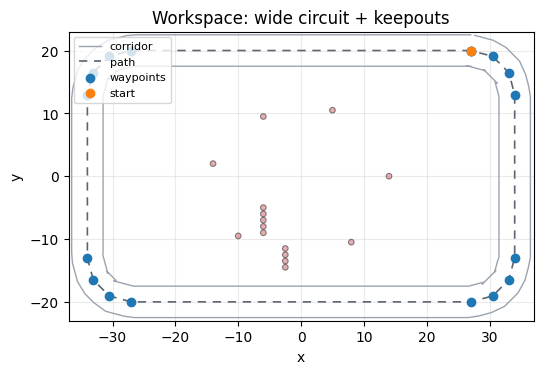

In [ ]:
def _quarter_arc(cx, cy, radius, angle_start, n=10):
    angles = np.linspace(angle_start, angle_start + np.pi / 2, n)
    return np.column_stack([cx + radius * np.cos(angles), cy + radius * np.sin(angles)])


def _join(*parts):
    out = np.asarray(parts[0], dtype=float)
    for part in parts[1:]:
        seg = np.asarray(part, dtype=float)
        if seg.size == 0:
            continue
        out = np.vstack([out, seg[1:]])
    return out


def wide_circuit_waypoints(
    *, cx=0.0, cy=0.0, width=34.0, height=20.0, r_fast=5.0, r_slow=3.5
):
    w2, h2 = width / 2.0, height / 2.0
    y_bot, y_top = cy - h2, cy + h2
    x_left, x_right = cx - w2, cx + w2
    r_br = r_tr = r_bl = r_fast
    r_tl = r_slow
    hx_br = x_right - r_br
    hx_tl = x_left + r_tl
    start = np.array([[x_left + 3.0, y_bot]])
    launch = np.linspace(start[0], [x_left + 10.0, y_bot], 4)[1:]
    chicane = np.array(
        [
            [x_left + 12.0, y_bot],
            [x_left + 14.0, y_bot + 1.8],
            [x_left + 16.0, y_bot],
            [hx_br - 1.5, y_bot],
        ]
    )
    arc_br = _quarter_arc(hx_br, y_bot + r_br, r_br, -np.pi / 2)[1:]
    right = np.linspace([x_right, y_bot + r_br], [x_right, y_top - r_tr], 5)[1:-1]
    arc_tr = _quarter_arc(hx_br, y_top - r_tr, r_tr, 0.0)[1:]
    top = np.linspace([hx_br, y_top], [hx_tl + 3.0, y_top], 5)[1:-1]
    arc_tl = _quarter_arc(hx_tl, y_top - r_tl, r_tl, np.pi / 2)[1:]
    left = np.linspace([x_left, y_top - r_tl], [x_left, y_bot + r_bl], 5)[1:-1]
    arc_bl = _quarter_arc(x_left + r_bl, y_bot + r_bl, r_bl, np.pi)[1:]
    return _join(
        start, launch, chicane, arc_br, right, arc_tr, top, arc_tl, left, arc_bl, start
    )


loop_xy = wide_circuit_waypoints(
    width=CIRCUIT_WIDTH,
    height=CIRCUIT_HEIGHT,
    r_fast=RADIUS_FAST,
    r_slow=RADIUS_SLOW,
)


path_raw = make_rectangle_path(Lx=CIRCUIT_WIDTH, Ly=CIRCUIT_HEIGHT)
# Rounded rectangle generated FROM the raw rectangle
path = make_rounded_rectangle_from_path(
    path_raw,
    R=7.0,
    nseg=4,
    narc=8,
    min_ds=0.1,
    closed=True,
)
loop_xy = path

track = ReferenceTrack(from_waypoints(loop_xy), half_width=CORRIDOR_HALF_WIDTH)
keepout_radius = OBSTACLE_RADIUS + OBSTACLE_MARGIN
scene = Scene(obstacles=[Sphere(c, keepout_radius) for c in OBSTACLE_CENTERS])
START_XY = loop_xy[0].copy()
PLOT_BOUNDS = (
    (loop_xy[:, 0].min() - PLOT_MARGIN, loop_xy[:, 0].max() + PLOT_MARGIN),
    (loop_xy[:, 1].min() - PLOT_MARGIN, loop_xy[:, 1].max() + PLOT_MARGIN),
)

print(f"lap length = {track.path.total_length:.2f} m")
_, ax = scene.plot(show=False, bounds=PLOT_BOUNDS, show_density=False, title="")
track.plot(show=False, ax=ax, bounds=PLOT_BOUNDS, title="")
ax.scatter([START_XY[0]], [START_XY[1]], c="C1", s=36, zorder=8, label="start")
ax.set_title("Workspace: wide circuit + keepouts")
ax.legend(loc="upper left", fontsize=8)
plt.show()


## Step 2 — Planner plant

Bounds on `sys_mpc` define the NLP box. Simulation plant `sys_sim` (later) can differ slightly (mass / inertia mismatch).


In [6]:
sys_mpc = JaxDynamicBicycleRateInputsUY()
sys_mpc.state.lower_bound[6] = 0.0
sys_mpc.state.upper_bound[6] = 90.0
sys_mpc.state.lower_bound[7] = -0.55
sys_mpc.state.upper_bound[7] = 0.55
sys_mpc.inputs["u"].lower_bound = np.array([-80.0, -2.0])
sys_mpc.inputs["u"].upper_bound = np.array([80.0, 2.0])
print(f"planner plant: n={sys_mpc.n}, m={sys_mpc.m}")


planner plant: n=8, m=2


## Step 3 — Soft spatial costs

`point_probe` heatmaps for intuition; `car_outline` body for the NLP. Soft costs use shaping (`quadratic_excess`, `quadratic_hinge`, `inverse_barrier`).


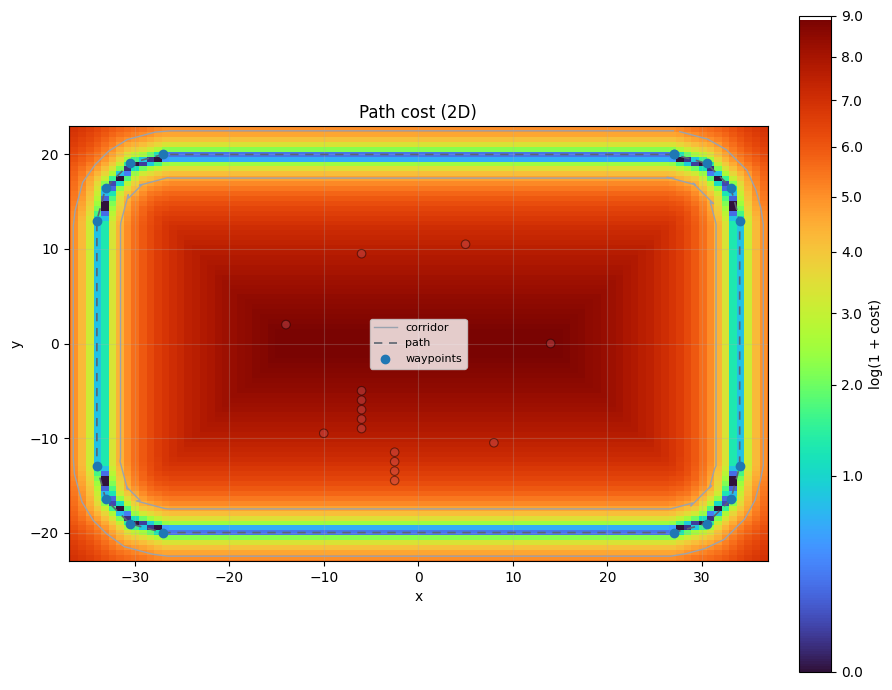

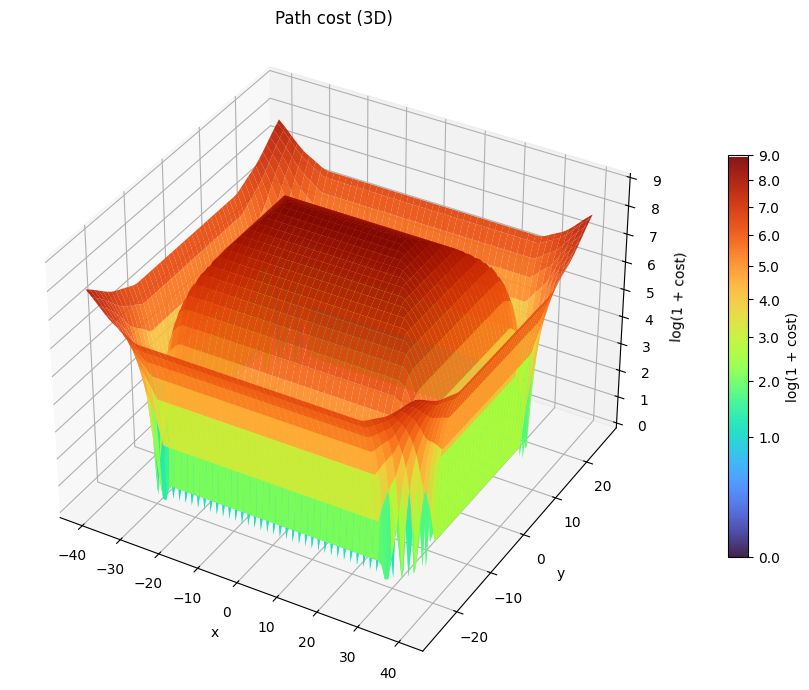

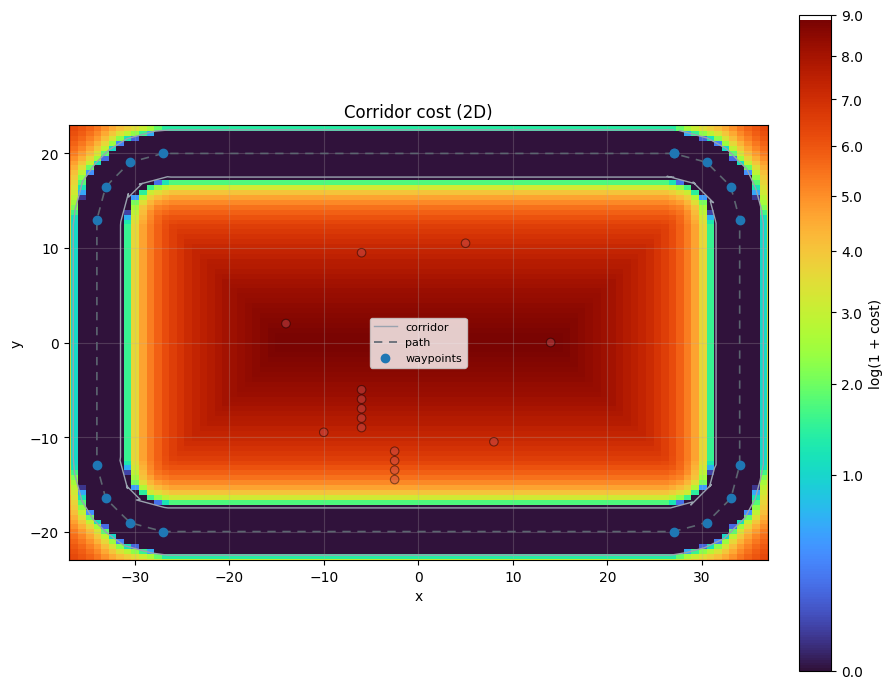

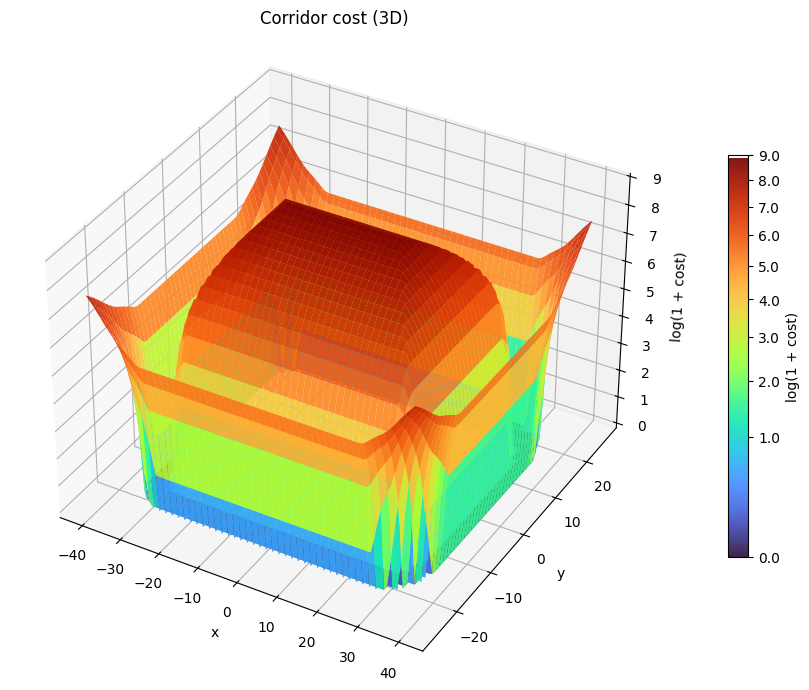

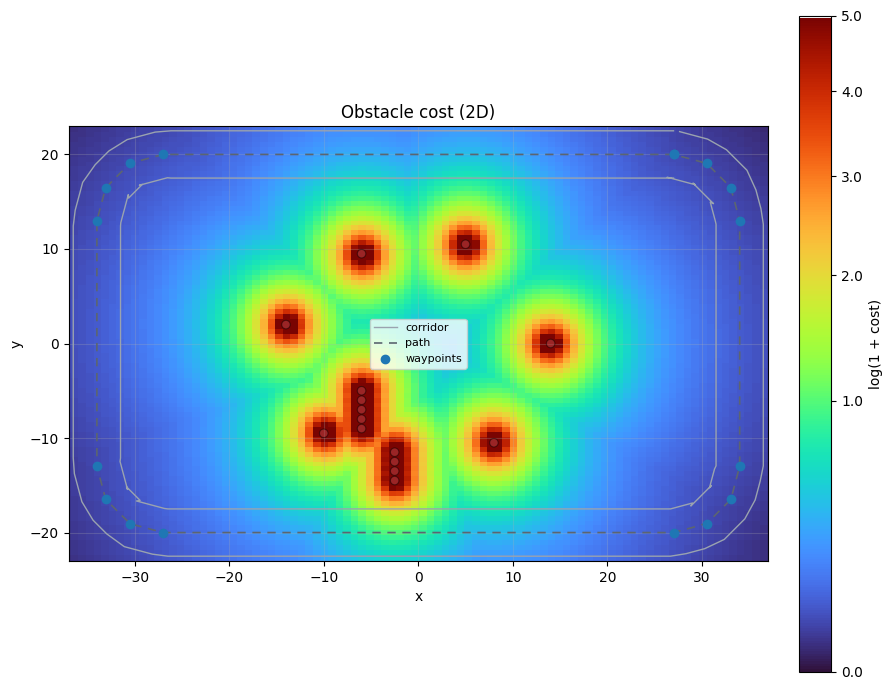

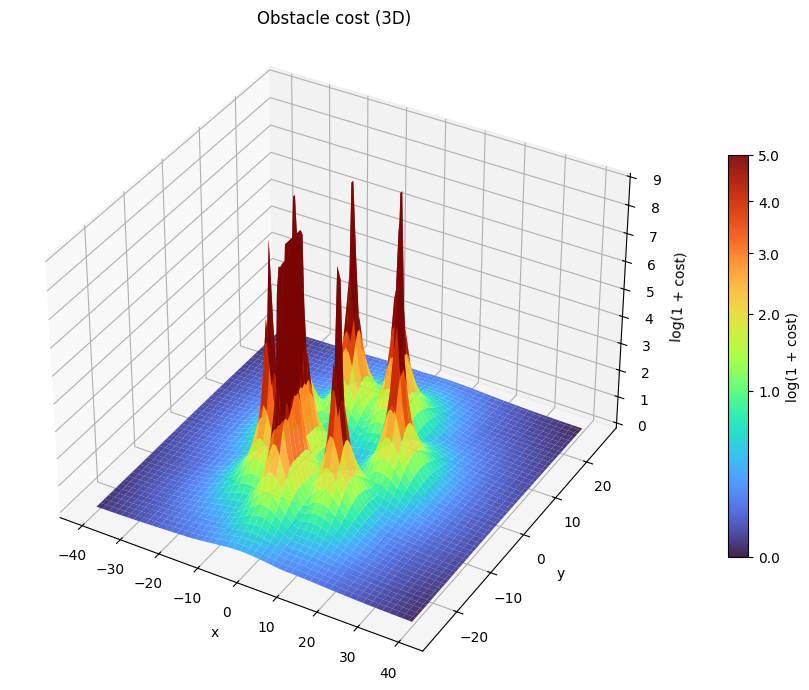

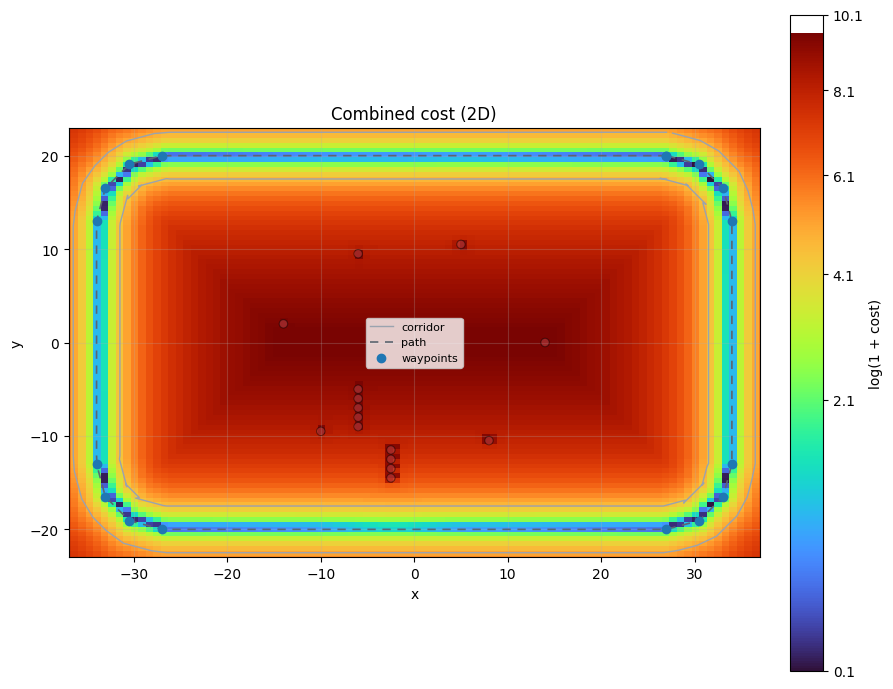

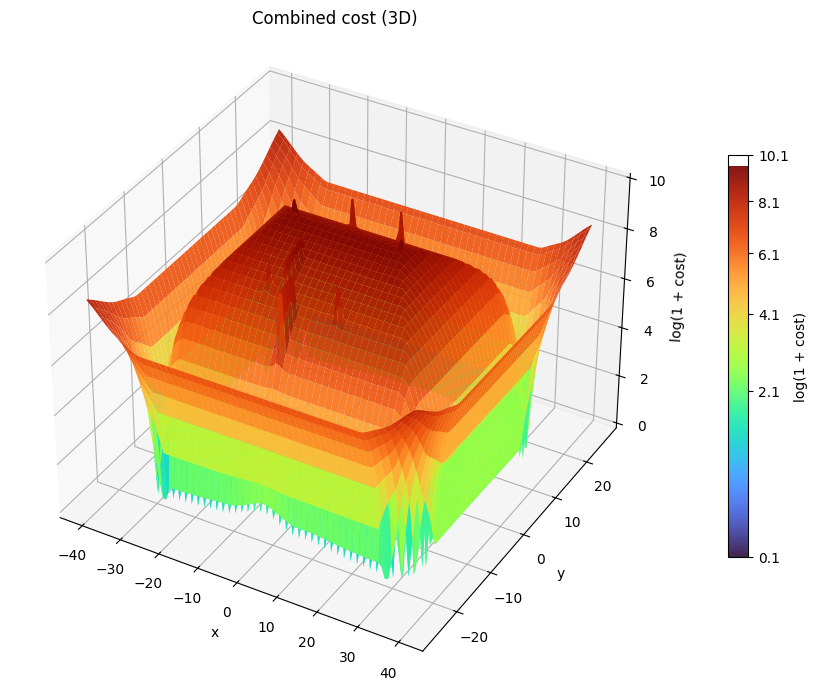

clearance @ x0 = 22.325 m


In [7]:
probe = bind(sys_mpc, point_probe())
body = bind(sys_mpc, car_outline(length=2.4, width=0.2, margin=0.05))

path_viz = track.distance_field(probe).as_cost(
    weight=PATH_COST_WEIGHT, shaping=quadratic_excess(threshold=0.1)
)
corridor_viz = track.corridor_field(probe).as_cost(
    weight=CORRIDOR_COST_WEIGHT, shaping=quadratic_hinge(threshold=0.0)
)
obstacle_viz = scene.clearance_field(probe).as_cost(
    weight=OBSTACLE_REPULSION_WEIGHT,
    shaping=inverse_barrier(epsilon=OBSTACLE_REPULSION_EPS),
)

if SHOW_PLOTS:
    cost_bounds = pad_bounds(PLOT_BOUNDS, COST_FIELD_MARGIN - PLOT_MARGIN)
    kw = dict(bounds=cost_bounds, state_dim=sys_mpc.n, grid=(100, 100))
    layers = {
        "path": sample_field_costs([path_viz], **kw),
        "corridor": sample_field_costs([corridor_viz], **kw),
        "obstacle": sample_field_costs([obstacle_viz], **kw),
        "combined": sample_field_costs([path_viz, corridor_viz, obstacle_viz], **kw),
    }
    plot_cost_field_exports(
        layers, track=track, scene=scene, overlay_bounds=PLOT_BOUNDS, log_scale=True, show=True
    )

r_r = sys_mpc.params["r_r"]
x_cruise = np.array([0.0, 0.0, 0.0, U_TARGET, 0.0, 0.0, U_TARGET / r_r, 0.0])
s_start, _ = track.path.project(START_XY)
tangent = track.path.tangent(s_start)
theta0 = float(np.arctan2(tangent[1], tangent[0]))
if abs(np.cos(2.0 * theta0)) > 1.0 - 1e-9:
    theta0 += 1e-4
x0 = np.array([START_XY[0], START_XY[1], theta0, VX0, 0.0, 0.0, VX0 / r_r, 0.0])

cost = (
    QuadraticCost.from_system(
        sys_mpc,
        Q=np.diag([0.0, 0.0, 0.0, 0.15, 4.0, 6.0, 0.1, 80.0]),
        R=np.diag([1.0, 22.0]),
        S=np.diag([0.0, 0.0, 0.0, 0.15, 4.0, 6.0, 0.1, 80.0]),
        xbar=x_cruise,
        ubar=np.zeros(2),
    )
    + track.distance_field(body).as_cost(
        weight=PATH_COST_WEIGHT, shaping=quadratic_excess(threshold=0.1)
    )
    + track.corridor_field(body).as_cost(
        weight=CORRIDOR_COST_WEIGHT, shaping=quadratic_hinge(threshold=0.0)
    )
    + scene.clearance_field(body).as_cost(
        weight=OBSTACLE_REPULSION_WEIGHT,
        shaping=inverse_barrier(epsilon=OBSTACLE_REPULSION_EPS),
    )
)
print(f"clearance @ x0 = {float(scene.clearance_field(body).value(x0)):.3f} m")


## Step 4 — `PlanningProblem` + one-horizon NLP

Same continuous problem, two views: manual `transcribe` → `Optimizer`, then the `TrajectoryOptimizationPlanner` wrapper (compile-once API used by MPC).


In [8]:
problem = PlanningProblem(sys=sys_mpc, x_start=x0, cost=cost, tf=MPC_HORIZON)

transcription = DirectCollocationTranscription(
    DirectCollocationOptions(n_steps=MPC_STEPS)
)
program = transcription.transcribe(problem, compile_backend="jax")
t_grid = transcription.initial_guess_time_grid(problem)
guess = default_initial_trajectory(problem, t_grid)
z0 = transcription.pack_initial_guess(problem, guess)
print(f"n_z = {program.n_z}")

optimizer = Optimizer(
    program,
    z0=z0,
    method="scipy_slsqp",
    options={"maxiter": MPC_MAXITER, "ftol": MPC_FTOL, "disp": False},
)
manual_result = optimizer.solve(record_solve_time=True)
manual_traj = transcription.reconstruct_result(
    manual_result, problem=problem, compile_backend="jax"
)
print(
    f"manual NLP: success={manual_result.success}, "
    f"J*={float(manual_result.cost):.3f}"
)

planner = TrajectoryOptimizationPlanner(
    problem,
    n_steps=MPC_STEPS,
    transcription="direct_collocation",
    compile_backend="jax",
    record_solve_time=True,
    optimizer_method="scipy_slsqp",
    optimizer_options={"maxiter": MPC_MAXITER, "ftol": MPC_FTOL},
)
plan = planner.solve()
print(f"planner: success={plan.metadata.success}, J*={float(plan.metadata.cost):.3f}")


n_z = 100
manual NLP: success=True, J*=143.196
planner: success=True, J*=143.196


## Step 5 — Receding-horizon deploy (`ModelPredictiveController` + hybrid)

Compile the parametric NLP once; each tick re-solves from measured $y$ with warm-start. Product composition `mpc @ plant` builds the `HybridDiagram`.


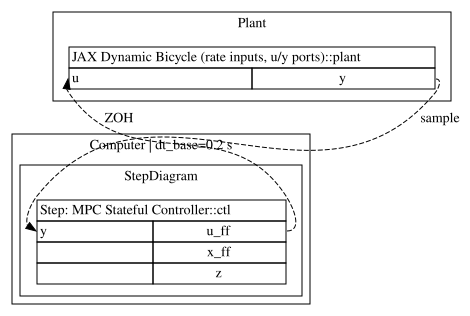

HybridSimulator: dt_base=0.2, n_ticks=120, t=[0.0, 24.0]
MPC @ t=0.00s  success=True  J=143.196  solve=0.118s  step=0.266s
MPC @ t=0.20s  success=True  J=132.481  solve=0.052s  step=0.064s
MPC @ t=0.40s  success=True  J=120.407  solve=0.014s  step=0.025s
MPC @ t=0.60s  success=True  J=109.476  solve=0.015s  step=0.026s
MPC @ t=0.80s  success=True  J=99.5363  solve=0.025s  step=0.036s
MPC @ t=1.00s  success=True  J=90.945  solve=0.010s  step=0.021s
MPC @ t=1.20s  success=True  J=82.0554  solve=0.025s  step=0.036s
MPC @ t=1.40s  success=True  J=74.8106  solve=0.018s  step=0.029s
MPC @ t=1.60s  success=True  J=68.3936  solve=0.013s  step=0.024s
MPC @ t=1.80s  success=True  J=62.3873  solve=0.019s  step=0.031s
MPC @ t=2.00s  success=True  J=57.1733  solve=0.014s  step=0.025s
MPC @ t=2.20s  success=True  J=52.4397  solve=0.020s  step=0.032s
MPC @ t=2.40s  success=True  J=48.365  solve=0.012s  step=0.023s
MPC @ t=2.60s  success=True  J=44.7696  solve=0.008s  step=0.021s
MPC @ t=2.80s  succes

In [ ]:
mpc = ModelPredictiveController(
    planner, dt_mpc=MPC_DT, warm_start=True, step_disp=True
)

sys_sim = JaxDynamicBicycleRateInputsUY()
sys_sim.params["mass"] = 1.03 * sys_mpc.params["mass"]
sys_sim.params["inertia"] = 1.02 * sys_mpc.params["inertia"]
sys_sim.camera_scale = 18.0
sys_sim.x0 = x0.copy()

hybrid = mpc @ sys_sim
hybrid.plot_diagram()

result = hybrid.compute_trajectory(
    tf=TF_SIM,
    x0_plant=x0,
    plant_dt_inner=SIM_DT,
    compile_backend="jax",
)
traj = result.plant
print(f"done: mean vx={float(np.mean(traj.x[3, :])):.2f} m/s")


## Step 6 — Results

Executed path on the circuit; animation overlays show planned horizons.


In [ ]:
fig, ax = track.plot(
    show=False, bounds=PLOT_BOUNDS, title="Hybrid MPC executed path"
)
scene.plot(show=False, ax=ax, bounds=PLOT_BOUNDS, show_density=False, title=None)
ax.plot(traj.x[0, :], traj.x[1, :], color="tab:blue", linewidth=1.8, label="executed")
ax.scatter([START_XY[0]], [START_XY[1]], c="C1", s=36, zorder=8, label="start")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

hybrid.plot_trajectory()
hybrid.animate(
    overlays=mpc_animation_overlays(result, planner, scene=scene, track=track)
)


---

**Pipeline:** workspace → fields → soft costs → `PlanningProblem` → trajopt NLP → `ModelPredictiveController` → `mpc @ plant` → `compute_trajectory`.

Scripts: [`demo_mpc_spatial.py`](../scripts/mpc/demo_mpc_spatial.py) (assemble only) · [`demo_mpc_circuit.py`](../scripts/mpc/demo_mpc_circuit.py) (hybrid closed loop).
